## Lab 2, Part 2: Overfitting
### Part 1: Dealing with overfitting

Today we work with [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) (*hint: it is available in `torchvision`*).

Your goal for today:
1. Train a FC (fully-connected) network that achieves >= 0.885 test accuracy.
2. Cause considerable overfitting by modifying the network (e.g. increasing the number of network parameters and/or layers) and demonstrate in in the appropriate way (e.g. plot loss and accurasy on train and validation set w.r.t. network complexity).
3. Try to deal with overfitting (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results.

__Please, write a small report describing your ideas, tries and achieved results in the end of this file.__

*Note*: Tasks 2 and 3 are interrelated, in task 3 your goal is to make the network from task 2 less prone to overfitting. Task 1 is independent from 2 and 3.

*Note 2*: We recommend to use Google Colab or other machine with GPU acceleration.

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchsummary
from IPython.display import clear_output
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import os


device = "cuda:0" if torch.cuda.is_available() else "cpu"

In [2]:
# Technical function
def mkdir(path):
    if not os.path.exists(root_path):
        os.mkdir(root_path)
        print("Directory", path, "is created!")
    else:
        print("Directory", path, "already exists!")


root_path = "fmnist"
mkdir(root_path)

Directory fmnist is created!


In [3]:
download = True
train_transform = transforms.ToTensor()
test_transform = transforms.ToTensor()
transforms.Compose((transforms.ToTensor()))


fmnist_dataset_train = torchvision.datasets.FashionMNIST(
    root_path, train=True, transform=train_transform, target_transform=None, download=download
)
fmnist_dataset_test = torchvision.datasets.FashionMNIST(
    root_path, train=False, transform=test_transform, target_transform=None, download=download
)

100%|██████████| 26.4M/26.4M [00:04<00:00, 5.77MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 674kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.69MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.5MB/s]


In [4]:
train_loader = torch.utils.data.DataLoader(
    fmnist_dataset_train, batch_size=128, shuffle=True, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    fmnist_dataset_test, batch_size=256, shuffle=False, num_workers=2
)

In [5]:
len(fmnist_dataset_test)

10000

In [6]:
for img, label in train_loader:
    print(img.shape)
    #     print(img)
    print(label.shape)
    print(label.size(0))
    break

torch.Size([128, 1, 28, 28])
torch.Size([128])
128


### Task 1
Train a network that achieves $\geq 0.885$ test accuracy. It's fine to use only Linear (`nn.Linear`) layers and activations/dropout/batchnorm. Convolutional layers might be a great use, but we will meet them a bit later.

In [19]:
class TinyNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28 * 28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),  # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here
            nn.Linear(input_shape, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, inp):
        out = self.model(inp)
        return out

In [20]:
torchsummary.summary(TinyNeuralNetwork().to(device), (28 * 28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
              ReLU-3                  [-1, 512]               0
            Linear-4                  [-1, 256]         131,328
              ReLU-5                  [-1, 256]               0
            Linear-6                  [-1, 128]          32,896
              ReLU-7                  [-1, 128]               0
            Linear-8                   [-1, 64]           8,256
              ReLU-9                   [-1, 64]               0
           Linear-10                   [-1, 10]             650
Total params: 575,050
Trainable params: 575,050
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 2.19
Estimated T

Your experiments come here:

In [21]:
model = TinyNeuralNetwork().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_func = nn.CrossEntropyLoss()

# Your experiments, training and validation loops here
n_epochs = 10
for epoch in range(n_epochs):
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        loss = loss_func(outputs, labels)
        opt.zero_grad()
        loss.backward()
        opt.step()
    
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            _, predicted = torch.max(outputs, 1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    print(f"Epoch {epoch}: accuracy = {acc:.4f}")


Epoch 0: accuracy = 0.8451
Epoch 1: accuracy = 0.8642
Epoch 2: accuracy = 0.8623
Epoch 3: accuracy = 0.8722
Epoch 4: accuracy = 0.8793
Epoch 5: accuracy = 0.8750
Epoch 6: accuracy = 0.8809
Epoch 7: accuracy = 0.8749
Epoch 8: accuracy = 0.8795
Epoch 9: accuracy = 0.8850


### Task 2: Overfit it.
Build a network that will overfit to this dataset. Demonstrate the overfitting in the appropriate way (e.g. plot loss and accurasy on train and test set w.r.t. network complexity).

*Note:* you also might decrease the size of `train` dataset to enforce the overfitting and speed up the computations.

In [35]:
class OverfittingNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28 * 28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),  # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here
            nn.Linear(input_shape, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.Linear(1024, 2048),
            nn.ReLU(),
            nn.Linear(2048, num_classes)
        )

    def forward(self, inp):
        out = self.model(inp)
        return out

In [30]:
torchsummary.summary(OverfittingNeuralNetwork().to(device), (28 * 28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
              ReLU-3                  [-1, 512]               0
            Linear-4                 [-1, 1024]         525,312
            Linear-5                   [-1, 10]          10,250
Total params: 937,482
Trainable params: 937,482
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 3.58
Estimated Total Size (MB): 3.60
----------------------------------------------------------------


In [32]:
subset_size = 5000
train_subset = torch.utils.data.Subset(fmnist_dataset_train, range(subset_size))
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=128, shuffle=True)

Epoch 1/10 | Train Loss: 0.9327, Train Acc: 0.6558 | Test Loss: 0.8893, Test Acc: 0.6373
Epoch 2/10 | Train Loss: 0.5720, Train Acc: 0.7892 | Test Loss: 0.6682, Test Acc: 0.7711
Epoch 3/10 | Train Loss: 0.4811, Train Acc: 0.8262 | Test Loss: 0.6275, Test Acc: 0.7681
Epoch 4/10 | Train Loss: 0.4111, Train Acc: 0.8490 | Test Loss: 0.5742, Test Acc: 0.8078
Epoch 5/10 | Train Loss: 0.3610, Train Acc: 0.8668 | Test Loss: 0.5276, Test Acc: 0.8170
Epoch 6/10 | Train Loss: 0.3360, Train Acc: 0.8764 | Test Loss: 0.5162, Test Acc: 0.8247
Epoch 7/10 | Train Loss: 0.3342, Train Acc: 0.8770 | Test Loss: 0.8767, Test Acc: 0.7548
Epoch 8/10 | Train Loss: 0.3969, Train Acc: 0.8594 | Test Loss: 0.5186, Test Acc: 0.8274
Epoch 9/10 | Train Loss: 0.2809, Train Acc: 0.8940 | Test Loss: 0.5114, Test Acc: 0.8263
Epoch 10/10 | Train Loss: 0.2821, Train Acc: 0.8942 | Test Loss: 0.6787, Test Acc: 0.8006


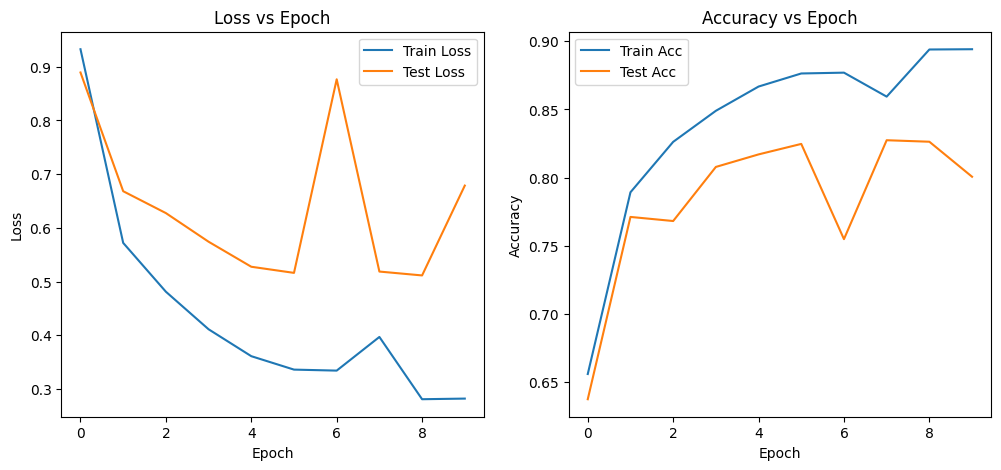

In [ ]:
model = OverfittingNeuralNetwork().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_func = nn.CrossEntropyLoss()

n_epochs = 10

train_loss_list = []
test_loss_list = []
train_acc_list = []
test_acc_list = []

for epoch in range(n_epochs):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        loss = loss_func(outputs, labels)
        
        train_loss += loss.item() * images.size(0)
        
        _, predicted = torch.max(outputs, 1)
        correct_train += predicted.eq(labels).sum().item()
        total_train += labels.size(0)
        
        opt.zero_grad()
        loss.backward()
        opt.step()
    
    train_loss /= total_train
    train_acc = correct_train / total_train

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    
    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            loss = loss_func(outputs, labels)
            test_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs, 1)
            correct_test += predicted.eq(labels).sum().item()
            total_test += labels.size(0)
    
    test_loss /= total_test
    test_acc = correct_test / total_test

    test_loss_list.append(test_loss)
    test_acc_list.append(test_acc)

    print(f"Epoch {epoch+1}/{n_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(test_loss_list, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(test_acc_list, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()

plt.show()


To overfit the model i decided to train it on a smaller dataset with a large number of parameters. As we can see after several epochs test loss starts increasing while train loss decreases. This is a sign of overfitting.

### Task 3: Fix it.
Fix the overfitted network from the previous step (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results. 

In [43]:
class FixedNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28 * 28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),  # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here
            nn.Linear(input_shape, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(1024, 2048),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(2048, num_classes)
        )

    def forward(self, inp):
        out = self.model(inp)
        return out

In [44]:
torchsummary.summary(FixedNeuralNetwork().to(device), (28 * 28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
              ReLU-3                  [-1, 512]               0
           Dropout-4                  [-1, 512]               0
            Linear-5                 [-1, 1024]         525,312
       BatchNorm1d-6                 [-1, 1024]           2,048
              ReLU-7                 [-1, 1024]               0
           Dropout-8                 [-1, 1024]               0
            Linear-9                 [-1, 2048]       2,099,200
             ReLU-10                 [-1, 2048]               0
          Dropout-11                 [-1, 2048]               0
           Linear-12                   [-1, 10]          20,490
Total params: 3,048,970
Trainable params: 3,048,970
Non-trainable params: 0
---------------------------

Epoch 1/10 | Train Loss: 1.0768, Train Acc: 0.6146 | Test Loss: 0.6434, Test Acc: 0.7645
Epoch 2/10 | Train Loss: 0.7255, Train Acc: 0.7350 | Test Loss: 0.6033, Test Acc: 0.7699
Epoch 3/10 | Train Loss: 0.6293, Train Acc: 0.7712 | Test Loss: 0.5393, Test Acc: 0.8039
Epoch 4/10 | Train Loss: 0.5530, Train Acc: 0.7986 | Test Loss: 0.5231, Test Acc: 0.8074
Epoch 5/10 | Train Loss: 0.5269, Train Acc: 0.8092 | Test Loss: 0.5658, Test Acc: 0.8011
Epoch 6/10 | Train Loss: 0.5733, Train Acc: 0.7916 | Test Loss: 0.5092, Test Acc: 0.8206
Epoch 7/10 | Train Loss: 0.5355, Train Acc: 0.8064 | Test Loss: 0.4985, Test Acc: 0.8152
Epoch 8/10 | Train Loss: 0.4842, Train Acc: 0.8226 | Test Loss: 0.5732, Test Acc: 0.7823
Epoch 9/10 | Train Loss: 0.4662, Train Acc: 0.8334 | Test Loss: 0.4927, Test Acc: 0.8283
Epoch 10/10 | Train Loss: 0.4656, Train Acc: 0.8328 | Test Loss: 0.4939, Test Acc: 0.8246


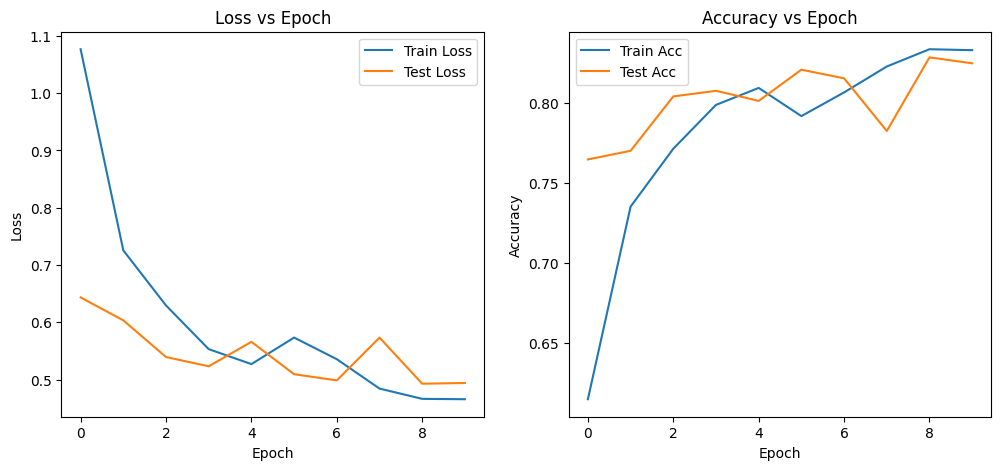

In [45]:
model = FixedNeuralNetwork().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_func = nn.CrossEntropyLoss()

# Your experiments, come here

n_epochs = 10

train_loss_list = []
test_loss_list = []
train_acc_list = []
test_acc_list = []

for epoch in range(n_epochs):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        loss = loss_func(outputs, labels)
        
        train_loss += loss.item() * images.size(0)
        
        _, predicted = torch.max(outputs, 1)
        correct_train += predicted.eq(labels).sum().item()
        total_train += labels.size(0)
        
        opt.zero_grad()
        loss.backward()
        opt.step()
    
    train_loss /= total_train
    train_acc = correct_train / total_train

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    
    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            loss = loss_func(outputs, labels)
            test_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs, 1)
            correct_test += predicted.eq(labels).sum().item()
            total_test += labels.size(0)
    
    test_loss /= total_test
    test_acc = correct_test / total_test

    test_loss_list.append(test_loss)
    test_acc_list.append(test_acc)

    print(f"Epoch {epoch+1}/{n_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(test_loss_list, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(test_acc_list, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()

plt.show()


### Conclusions:
_Write down small report with your conclusions and your ideas._

In this part, I tried to reduce overfitting of the model from Task 2. Added dropout layers and batch normalization to the network. Dropout randomly disables neurons during training, while batch normalization stabilizes the activations inside the network.
As a result, the gap between training and test performance became smaller and the test accuracy became more stable.